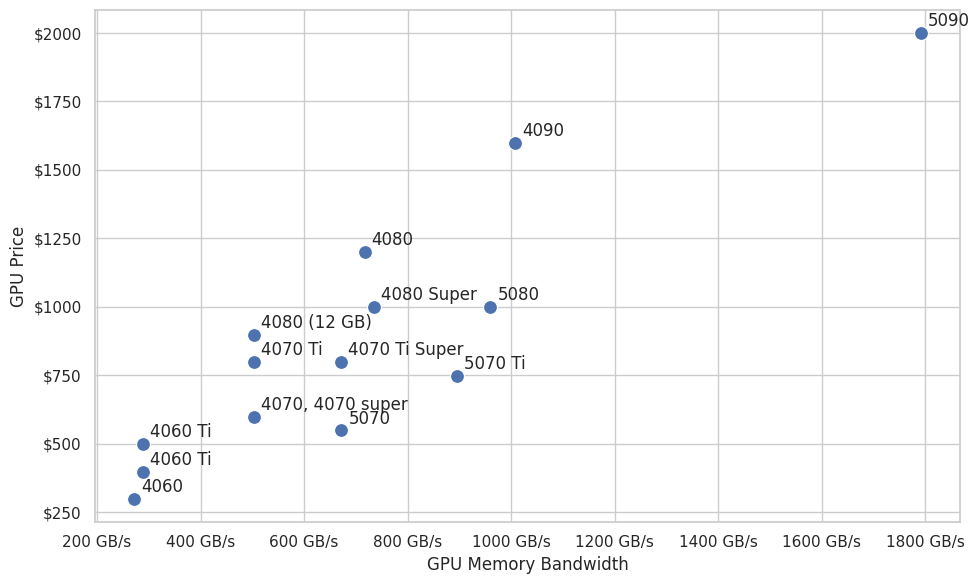

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# GPU data
plt.rcParams['font.size'] = 15
gpu_names = [
    "4060", "4060 Ti", "4060 Ti",
    "4070", "4070 Super", "4070 Ti",
    "4070 Ti Super", "4080 (12 GB)", "4080",
    "4080 Super", "4090",
    "5070", "5070 Ti", "5080", "5090"
]
gpu_bandwidth = [272, 288, 288, 504, 504, 504, 672, 504.2, 716.8, 736, 1008, 672, 896, 960, 1792]
gpu_prices = [299, 399, 499, 599, 599, 799, 799, 899, 1199, 999, 1599, 549, 749, 999, 1999]

# Set seaborn style
sns.set(style="whitegrid")

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=gpu_bandwidth, y=gpu_prices, s=100, color='b')

# Annotate each point
for name, x, y in zip(gpu_names, gpu_bandwidth, gpu_prices):
    if name != "4070":
        if name == "4070 Super":
            name = "4070, 4070 super"
        plt.annotate(name, (x, y), textcoords="offset points", xytext=(5,5))

# Labels and title
plt.xlabel("GPU Memory Bandwidth")
plt.ylabel("GPU Price")
# Format y-axis in dollars
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x)}"))
# And set x-axis in GB/s
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)} GB/s"))
# plt.title("GPU Price vs Memory Bandwidth")
# plt.yticks(range(0, 2200, 200)
# Add format in
plt.tight_layout()

# Show plot
plt.savefig("gpu_price_vs_bandwidth.png", dpi=600)
plt.show()

In [1]:
from matchms import calculate_scores
from matchms.importing import load_from_mgf
from simms.similarity import (
CudaCosineGreedy,
CudaFingerprintSimilarity,
CudaModifiedCosine,
)
from simms.utils import download

sample_file = download("pesticides.mgf")
references = list(load_from_mgf(sample_file))
queries = list(load_from_mgf(sample_file))

similarity_function = CudaCosineGreedy()

scores = calculate_scores(
    references=references,
    queries=queries,
    similarity_function=similarity_function,
)
